# Figure 2 — Expected runtime with restart on failure

**Paper location:** Section 6.1, Fig. 2.

## What this figure shows

A *second*, independent advantage of the Rodeo realization — its behaviour when a
filtering attempt **fails**. Both filters have essentially the same single-run
success probability `P → 4/7` in the resolved regime, but they pay very different
prices for a failed attempt:

- **QPE** has a single terminal measurement, so a failure is only detected after the
  *entire* circuit of depth `T_QPE` has run. The expected total depth to one success
  is `T_QPE / P` — a fixed `1/P = 7/4 = 1.75×` overhead on **every** attempt.
- **Rodeo** measures cycle by cycle and aborts at the first failed outcome, so a
  failed attempt typically consumes only the first few cycles. The overhead is only
  `~1.03–1.1` and *shrinks* with precision.

Panel (a) shows the expected total depth with restarts (solid) against the
single-successful-run depth (faint); panel (b) shows the overhead ratio
`T_tot / T_single`.

## Model & comparison

| | |
|---|---|
| **Model** | single spin, `g = 1/2` (same as Fig. 1) |
| **Compared** | QPE terminal-measurement restart vs Rodeo cycle-by-cycle early abort |
| **Restart model** | exact: failed Rodeo attempt costs only the depth accumulated before the first failed cycle |
| **Key number** | QPE overhead pinned at `1/P = 1.75`; Rodeo overhead `~1.03–1.1`, decreasing |

This is the `O(1/g)`-per-failed-attempt behaviour: combined with the depth scaling of
Fig. 1, the expected-total-depth advantage at `ε = 10⁻⁸` grows to roughly `1.8×10²`.
The benchmark assumes ideal, postselection-free success statistics in a
fault-tolerant setting.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../reproduce/core"))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
C_QPE, C_RG, C_RD, GREY = "#0072B2", "#D55E00", "#009E73", "#BBBBBB"

from cost_compare import (G, qpe_epsilon, qpe_depth,
    rodeo_epsilon_deterministic, rodeo_depth_deterministic)
from restart_cost import qpe_expected_total_depth, rodeo_expected_total_depth_det
H, A_DET = 0.5, 3.0
print(f"single-spin gap g = {G}, success prob P = 4/7 = {4/7:.3f}")


single-spin gap g = 0.5, success prob P = 4/7 = 0.571


### Sweep target precision and accumulate restart cost

In [2]:
# Draft model: in the resolved regime BOTH filters have the SAME single-run
# success probability P = |c0|^2 + |c1|^2 = 4/7 (the zero-sector weight of the
# input state). QPE detects failure only at the end -> overhead 1/P. Rodeo aborts
# at the first failed cycle (Eq. 32), so its overhead is much smaller.
from cost_compare import (G, qpe_epsilon, qpe_depth,
    rodeo_epsilon_deterministic, rodeo_depth_deterministic, deterministic_schedule)
from restart_cost import eigen_weights

P = 4/7  # resolved-regime single-run success probability (both filters)

def rodeo_total_with_restart(h, n, a_det):
    """Expected total depth with early-abort restart, Eq. (32), at fixed P=4/7."""
    phis, w = eigen_weights(h)
    times = deterministic_schedule(n, a_det)
    Dk = np.cumsum(np.abs(times))
    f = np.cumprod(np.cos(np.outer(phis, times)/2.0), axis=1)
    W = np.empty(n+1); W[0] = 1.0
    for k in range(1, n+1):
        W[k] = float(np.sum(w * f[:, k-1]**2))
    # normalize survival so the conditional success matches P (resolved regime)
    fail_term = sum((W[k-1] - W[k]) * Dk[k-1] for k in range(1, n+1))
    return fail_term / P + Dk[-1]

targets = np.logspace(-1.5, -8, 20)
qs, qt, ds, dt, pr = [], [], [], [], []
for tg in targets:
    t = next((tt for tt in range(1,30) if qpe_epsilon(H,tt) <= tg), None)
    n = next((nn for nn in range(1,90) if rodeo_epsilon_deterministic(H,nn,A_DET) <= tg), None)
    if t is None or n is None: continue
    s_q = qpe_depth(t)
    qs.append(s_q); qt.append(s_q / P)                     # QPE: overhead exactly 1/P
    s_d = rodeo_depth_deterministic(n, A_DET)
    ds.append(s_d); dt.append(rodeo_total_with_restart(H, n, A_DET))
    pr.append(np.log10(1/tg))
qs,qt,ds,dt,pr = map(np.array,(qs,qt,ds,dt,pr))
print(f"swept {len(pr)} precisions")
print(f"QPE overhead = 1/P = {1/P:.2f} (constant); Rodeo overhead {(dt/ds).min():.3f}-{(dt/ds).max():.3f}")

swept 20 precisions
QPE overhead = 1/P = 1.75 (constant); Rodeo overhead 1.036-1.153


### Figure

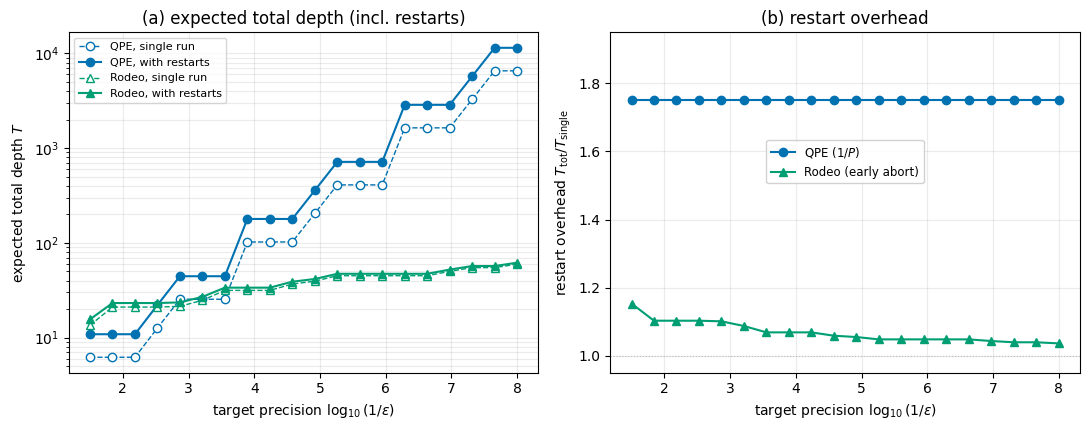

In [3]:
fig,(axa,axb)=plt.subplots(1,2,figsize=(11,4.4))
# (a) expected total depth
axa.semilogy(pr,qs,"o--",color=C_QPE,mfc="white",lw=1.0,label="QPE, single run")
axa.semilogy(pr,qt,"o-",color=C_QPE,label="QPE, with restarts")
axa.semilogy(pr,ds,"^--",color=C_RD,mfc="white",lw=1.0,label="Rodeo, single run")
axa.semilogy(pr,dt,"^-",color=C_RD,label="Rodeo, with restarts")
axa.set_xlabel(r"target precision $\log_{10}(1/\varepsilon)$")
axa.set_ylabel(r"expected total depth $T$")
axa.set_title("(a) expected total depth (incl. restarts)")
axa.legend(loc="upper left",fontsize=8); axa.grid(alpha=0.25,which="both")
# (b) restart overhead -- legend placed in the empty mid-region, away from curves
axb.plot(pr,qt/qs,"o-",color=C_QPE,label=r"QPE ($1/P$)")
axb.plot(pr,dt/ds,"^-",color=C_RD,label="Rodeo (early abort)")
axb.axhline(1.0,color=GREY,lw=0.8,ls=":")
axb.set_ylim(0.95,1.95)
axb.set_xlabel(r"target precision $\log_{10}(1/\varepsilon)$")
axb.set_ylabel(r"restart overhead $T_{\rm tot}/T_{\rm single}$")
axb.set_title("(b) restart overhead")
axb.legend(loc="center", bbox_to_anchor=(0.5,0.62), fontsize=8.5,
           framealpha=0.9, edgecolor="0.8")
axb.grid(alpha=0.25)
fig.tight_layout(); fig.savefig("fig_restart.pdf",bbox_inches="tight"); plt.show()